SHAPE (rows, cols): (78792, 21)

COLUMNS: ['Year', 'LocationAbbr', 'LocationDesc', 'GeographicLevel', 'DataSource', 'Class', 'Topic', 'Data_Value', 'Data_Value_Unit', 'Data_Value_Type', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'StratificationCategory1', 'Stratification1', 'StratificationCategory2', 'Stratification2', 'TopicID', 'LocationID', 'Y_lat', 'X_lon', 'Georeference']


,Year,LocationAbbr,LocationDesc,GeographicLevel,DataSource,Class,Topic,Data_Value,Data_Value_Unit,Data_Value_Type,...,Data_Value_Footnote,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,TopicID,LocationID,Y_lat,X_lon,Georeference
0,2020,AS,American Samoa County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,NaN,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Insufficient Data,Sex,Male,Race/Ethnicity,Black,T2,60000,-14.301754,-170.719474,POINT (-170.7194738 -14.30175426)
1,2020,ND,North Dakota,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,NaN,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,Insufficient Data,Sex,Female,Race/Ethnicity,Asian,T2,38,47.447100,-100.470000,POINT (-100.47 47.4471)
2,2020,PA,Pennsylvania,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,616.0,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Male,Race/Ethnicity,Black,T2,42,40.874900,-77.802200,POINT (-77.8022 40.8749)
3,2020,CA,California,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,229.5,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Overall,Race/Ethnicity,Hispanic,T2,6,37.241400,-119.601000,POINT (-119.601 37.2414)
4,2020,IA,Iowa,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,190.6,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Overall,Race/Ethnicity,Asian,T2,19,42.076000,-93.502200,POINT (-93.5022 42.076)



INFO:
<class 'pandas.DataFrame'>
RangeIndex: 78792 entries, 0 to 78791
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        78792 non-null  int64  
 1   LocationAbbr                78792 non-null  str    
 2   LocationDesc                78792 non-null  str    
 3   GeographicLevel             78792 non-null  str    
 4   DataSource                  78792 non-null  str    
 5   Class                       78792 non-null  str    
 6   Topic                       78792 non-null  str    
 7   Data_Value                  34430 non-null  float64
 8   Data_Value_Unit             78792 non-null  str    
 9   Data_Value_Type             78792 non-null  str    
 10  Data_Value_Footnote_Symbol  44362 non-null  str    
 11  Data_Value_Footnote         44362 non-null  str    
 12  StratificationCategory1     78792 non-null  str    
 13  Stratification1             78792 n

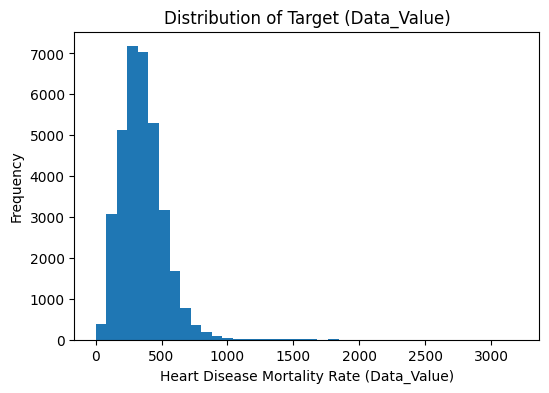

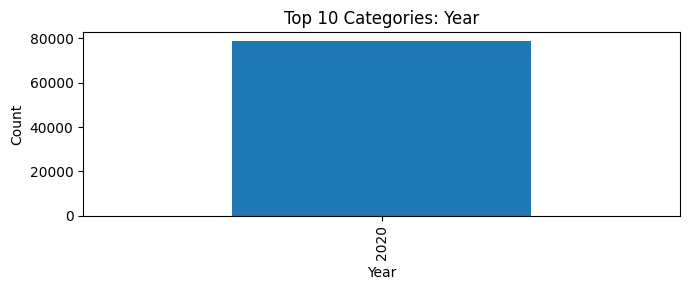

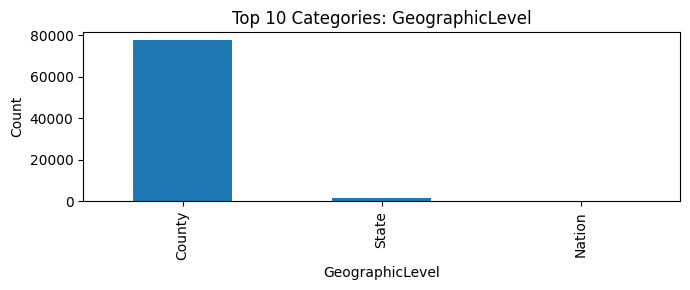

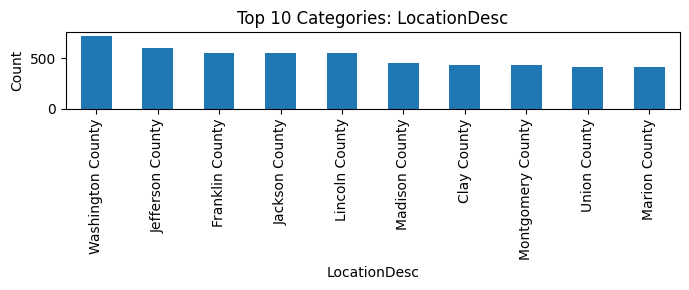

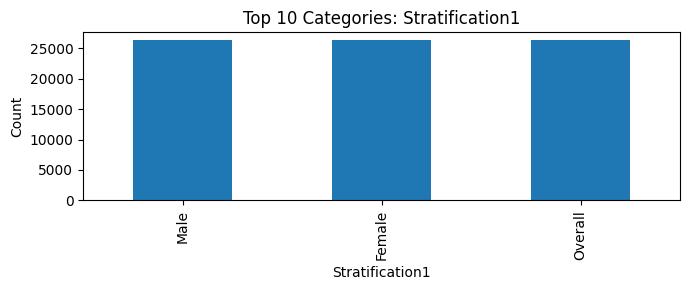

C:\Users\bista\AppData\Local\Temp\ipykernel_45116\1132378630.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


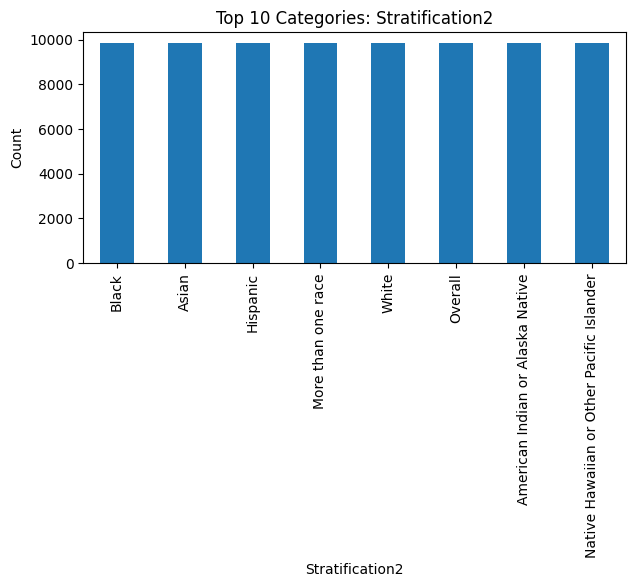

C:\Users\bista\AppData\Local\Temp\ipykernel_45116\1132378630.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


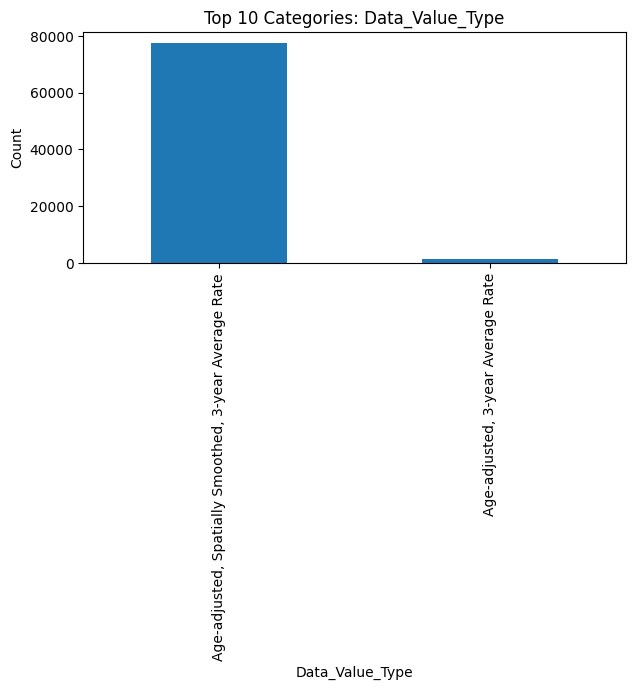


EXAMPLE QUESTIONS THIS DATA CAN ANSWER:
1) Which states/counties have higher heart disease mortality rates?
2) Do mortality rates differ by sex or age group (stratifications)?
3) Do rates change across years 2019–2021?

CLEANED SHAPE (after dropping missing target): (34430, 21)

COLUMNS AFTER DROPS: ['Year', 'LocationAbbr', 'LocationDesc', 'GeographicLevel', 'DataSource', 'Class', 'Topic', 'Data_Value', 'Data_Value_Unit', 'Data_Value_Type', 'StratificationCategory1', 'Stratification1', 'StratificationCategory2', 'Stratification2', 'TopicID', 'LocationID', 'Y_lat', 'X_lon']


In [ ]:

# TASK 1: Exploratory Data Analysis (EDA) + Data Understanding (REGRESSION)
# Dataset: Heart Disease Mortality (2019–2021)
# Target Variable (Proposal): Heart Disease Mortality Rate
# Target Column (CSV): Data_Value
# UN SDG Alignment: SDG 3 - Good Health & Well-Being


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  1) LOAD DATASET (COLAB FRIENDLY) ----
file_name = "Heart_Disease_Mortality_Data_Among_US_Adults__35___by_State_Territory_and_County___2019-2021.csv"

try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)

print("SHAPE (rows, cols):", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
display(df.head())

# 2) BASIC INFO ----
print("\nINFO:")
df.info()

# 3) MISSING VALUES ----
print("\nMISSING VALUES PER COLUMN:")
print(df.isna().sum())

# 4) TARGET COLUMN CHECK ----
target_col = "Data_Value"

# Convert target to numeric (some datasets include non-numeric or missing entries)
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

print("\nTARGET SUMMARY (Data_Value):")
print(df[target_col].describe())

# Plot target distribution (no heatmap)
plt.figure(figsize=(6,4))
plt.hist(df[target_col].dropna(), bins=40)
plt.title("Distribution of Target (Data_Value)")
plt.xlabel("Heart Disease Mortality Rate (Data_Value)")
plt.ylabel("Frequency")
plt.show()

# ---- 5) QUICK LOOK AT CATEGORICAL DISTRIBUTIONS (few important columns) ----
cat_preview_cols = ["Year", "GeographicLevel", "LocationDesc", "Stratification1", "Stratification2", "Data_Value_Type"]
cat_preview_cols = [c for c in cat_preview_cols if c in df.columns]

for col in cat_preview_cols:
    plt.figure(figsize=(7,3))
    df[col].astype("str").value_counts().head(10).plot(kind="bar")
    plt.title(f"Top 10 Categories: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# ---- 6) SIMPLE QUESTIONS THIS DATA CAN ANSWER (FOR REPORT) ----
print("\nEXAMPLE QUESTIONS THIS DATA CAN ANSWER:")
print("1) Which states/counties have higher heart disease mortality rates?")
print("2) Do mortality rates differ by sex or age group (stratifications)?")
print("3) Do rates change across years 2019–2021?")

# ---- 7) PREPARE CLEAN DATA COPY FOR MODELING ----
df_clean = df.copy()

# Drop rows where target is missing (cannot train on missing target)
df_clean = df_clean.dropna(subset=[target_col])

print("\nCLEANED SHAPE (after dropping missing target):", df_clean.shape)

# Remove columns that are mostly notes/footnotes or hard-to-use text blobs
drop_cols = [
    "Data_Value_Footnote_Symbol",
    "Data_Value_Footnote",
    "Georeference"
]
drop_cols = [c for c in drop_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

print("\nCOLUMNS AFTER DROPS:", df_clean.columns.tolist())


In [ ]:

# TASK 2: Neural Network Regressor (MLPRegressor)
# - Train/Test split
# - Preprocessing (impute + one-hot encode)
# - Train + Evaluate using MAE, RMSE, R2


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target_col = "Data_Value"

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Preprocess: impute + scale numeric, impute + one-hot encode categorical
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlp_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=42
    ))
])

mlp_reg.fit(X_train, y_train)
pred = mlp_reg.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MLPRegressor (Neural Network) Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


C:\Users\bista\AppData\Local\Temp\ipykernel_45116\4081417237.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


MLPRegressor (Neural Network) Performance:
MAE : 45.52890730040571
RMSE: 74.67877372697774
R2  : 0.7804067894878908


C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:

# TASK 3: Two Classical Regression Models (Non-NN)
# Models:
# 1) Ridge Regression
# 2) Random Forest Regressor
# Evaluate using MAE, RMSE, R2


from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(random_state=42))
])

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

ridge_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

def print_reg_metrics(name, y_true, y_hat):
    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    r2 = r2_score(y_true, y_hat)
    print(f"\n{name} Performance:")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

print_reg_metrics("Ridge Regression", y_test, ridge_pred)
print_reg_metrics("Random Forest Regressor", y_test, rf_pred)



Ridge Regression Performance:
MAE : 58.86052431448356
RMSE: 89.294128087729
R2  : 0.6860428671697112

Random Forest Regressor Performance:
MAE : 40.03269009584663
RMSE: 74.83400455294276
R2  : 0.7794929270387481


In [ ]:

# TASK 4: Hyperparameter Tuning with Cross-Validation (GridSearchCV)
# - Tune Ridge + RandomForest
# - Report best params + best CV score (neg RMSE)


from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Ridge tuning
ridge_params = {
    "model__alpha": [0.1, 1.0, 10.0, 50.0]
}

ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_params,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("BEST Ridge Params:", ridge_grid.best_params_)
print("BEST Ridge CV (neg RMSE):", ridge_grid.best_score_)

# Random Forest tuning
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("\nBEST RF Params:", rf_grid.best_params_)
print("BEST RF CV (neg RMSE):", rf_grid.best_score_)


BEST Ridge Params: {'model__alpha': 1.0}
BEST Ridge CV (neg RMSE): -91.16376755721845

BEST RF Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
BEST RF CV (neg RMSE): -77.32008772871446


In [ ]:

# TASK 5: Feature Selection (Filter Method: SelectKBest f_regression)
# - Apply feature selection after preprocessing (works with one-hot)
# - Do it for both tuned models


from sklearn.feature_selection import SelectKBest, f_regression

# pick k safely (not too large)
k = 30

selector = SelectKBest(score_func=f_regression, k=k)

ridge_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("model", Ridge(random_state=42, alpha=ridge_grid.best_params_["model__alpha"]))
])

rf_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=rf_grid.best_params_["model__n_estimators"],
        max_depth=rf_grid.best_params_["model__max_depth"],
        min_samples_split=rf_grid.best_params_["model__min_samples_split"]
    ))
])

ridge_fs.fit(X_train, y_train)
rf_fs.fit(X_train, y_train)

print("Feature Selection applied using SelectKBest(f_regression) with k =", k)


C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\feature_selection\_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)
C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\feature_selection\_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)


Feature Selection applied using SelectKBest(f_regression) with k = 30


In [ ]:

# TASK 6: Final Models + Comparison Table
# - Final Ridge + Final RandomForest using tuned params + selected features
# - Evaluate on test set
# - Create a comparison table (CV score, Test RMSE, Test R2)


import pandas as pd

# Predictions
ridge_final_pred = ridge_fs.predict(X_test)
rf_final_pred = rf_fs.predict(X_test)

def reg_row(model_name, y_true, y_hat, best_cv_score):
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    r2 = r2_score(y_true, y_hat)
    mae = mean_absolute_error(y_true, y_hat)
    return {
        "Model": model_name,
        "CV Best (neg RMSE)": best_cv_score,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2
    }

comparison = []
comparison.append(reg_row("Ridge (Tuned + Selected)", y_test, ridge_final_pred, ridge_grid.best_score_))
comparison.append(reg_row("RandomForest (Tuned + Selected)", y_test, rf_final_pred, rf_grid.best_score_))

comparison_df = pd.DataFrame(comparison)
display(comparison_df)


,Model,CV Best (neg RMSE),Test MAE,Test RMSE,Test R2
0,Ridge (Tuned + Selected),-91.163768,69.769220,101.852691,0.591521
1,RandomForest (Tuned + Selected),-77.320088,61.549771,98.582290,0.617332
